In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import CountVectorizer
count = CountVectorizer()


In [21]:
data = pd.read_csv('/content/Train.csv', engine='python', on_bad_lines='skip')
print(data.shape)
data.head()

(25558, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


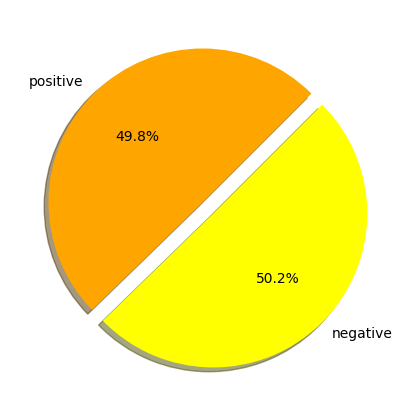

In [22]:
fig = plt.figure(figsize = (5,5))
colors = ["orange","yellow"]
pos = data[data['label']==1]
neg = data[data['label']==0]
ck = [pos['label'].count(),neg['label'].count()]
legpie = plt.pie(ck,labels=["positive","negative"],
                 autopct = '%1.1f%%',
                 shadow = True,
                 colors = colors,
                 startangle = 45,
                 explode = (0,0.1)
                 )

we will import RE, that is, the regular expression operation, we use this library to remove html tags

In [23]:
import re
def preprocessor(text):
  text = re.sub('<[^>]*>','',text)
  emojis=re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)',text)
  text=re.sub('[\W]+',' ',text.lower()) +\
  ' '.join(emojis).replace('-','')
  return text



In [24]:
data['text'] = data['text'].apply(preprocessor)
data['text']

,text
0,i grew up b 1965 watching and loving the thund...
1,when i put this movie in my dvd player and sat...
2,why do people who do not know what a particula...
3,even though i have great interest in biblical ...
4,im a die hard dads army fan and nothing will e...
...,...
25553,ok maybe a 13 year old like me was a little to...
25554,as a young teenager at the time airwolf was co...
25555,clint eastwood has definitely produced better ...
25556,i could never remember the name of this show i...


nltk’s PorterStemmer to simplify the data and remove unnecessary complexities in our text data:

In [25]:
from nltk.stem.porter import PorterStemmer
porter = PorterStemmer()
def tokenizer(text):
  return text.split()
def tokenizer_porter(text):
  return [porter.stem(word) for word in text.split()]

In [26]:
tokenized_text = data['text'].apply(tokenizer_porter)
tokenized_text

,text
0,"[i, grew, up, b, 1965, watch, and, love, the, ..."
1,"[when, i, put, thi, movi, in, my, dvd, player,..."
2,"[whi, do, peopl, who, do, not, know, what, a, ..."
3,"[even, though, i, have, great, interest, in, b..."
4,"[im, a, die, hard, dad, armi, fan, and, noth, ..."
...,...
25553,"[ok, mayb, a, 13, year, old, like, me, wa, a, ..."
25554,"[as, a, young, teenag, at, the, time, airwolf,..."
25555,"[clint, eastwood, ha, definit, produc, better,..."
25556,"[i, could, never, rememb, the, name, of, thi, ..."


#Visualizing Negative and Positive Words

In [27]:
# Importing stop words

In [28]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [29]:
# Import wordcloud

from wordcloud import WordCloud


positive_data = data[data['label']==1]
pos_data = positive_data['text']
negative_data = data[data['label']==0]
neg_data = negative_data['text']

In [30]:
positive_data

,text,label
4,im a die hard dads army fan and nothing will e...,1
6,finally watched this shocking movie last night...,1
8,it may be the remake of 1987 autumn s tale aft...,1
9,my super ex girlfriend turned out to be a plea...,1
10,i can t believe people are looking for a plot ...,1
...,...,...
25552,not for the squeamish but the number of twists...,1
25554,as a young teenager at the time airwolf was co...,1
25555,clint eastwood has definitely produced better ...,1
25556,i could never remember the name of this show i...,1


In [31]:
def wordcloud_draw(data,color = 'white'):
  words = ' '.join(data)
  cleaned_word = " ".join([word for word in words.split()
                                if (word !='movie' and word != 'film')
                                ])
  wordcloud = WordCloud(stopwords = stop,background_color = color,

                        width = 2500,
                        height = 2000
                        ).generate(cleaned_word)

  plt.figure(1,figsize = (10,7))
  plt.imshow(wordcloud)
  plt.axis('off')
  plt.show()



Positive wordcloud are as follows


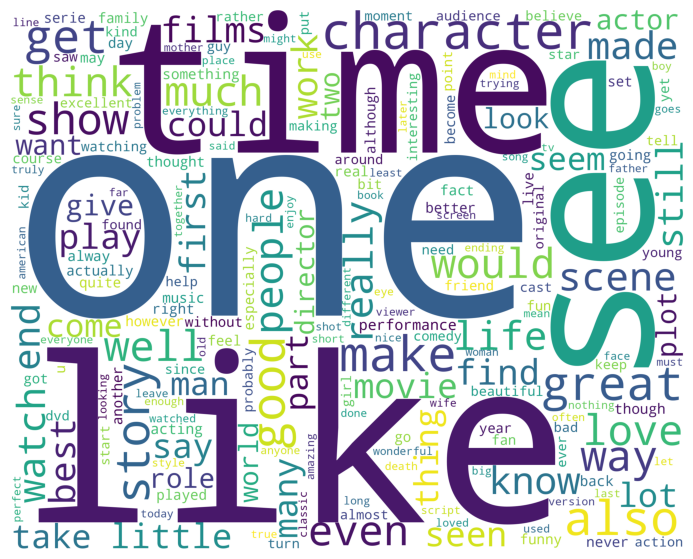

In [32]:
  print('Positive wordcloud are as follows')
  wordcloud_draw(pos_data,'white')

Negative wordcloud are as follows


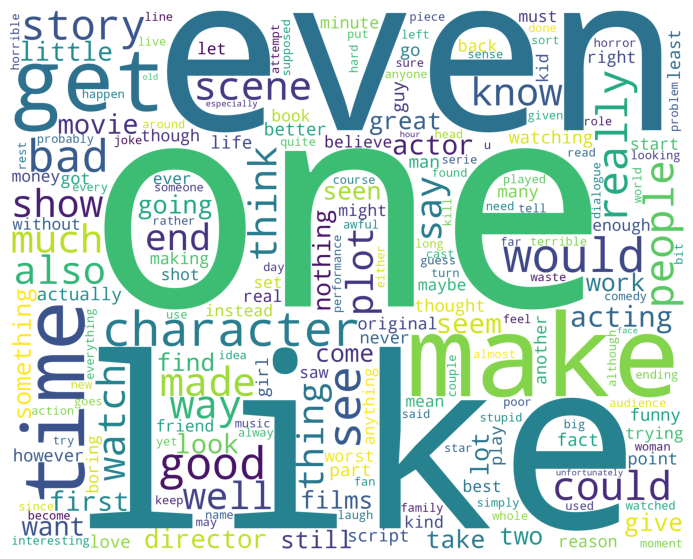

In [33]:
  print('Negative wordcloud are as follows')
  wordcloud_draw(neg_data)

TF-IDF Vertorizer to convert the raw documents into feature matrix which is very important to train a Machine Learning model:

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        preprocessor=None,
                        tokenizer = tokenizer_porter,
                        use_idf=True)

In [35]:
y = data.label.values
y

array([0, 0, 0, ..., 1, 1, 1])

In [36]:
x = tfidf.fit_transform(data.text.values)


In [37]:
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3460970 stored elements and shape (25558, 54370)>

# **Training Machine Learning Model for Sentiment Analysis**

In [38]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=1,test_size=0.5,shuffle=False)


In [39]:
from sklearn.linear_model import LogisticRegressionCV

clf = LogisticRegressionCV(cv=5,
                           scoring='accuracy',
                           random_state=0,
                           n_jobs=-1,
                           verbose=3,
                           max_iter=300).fit(x_train,y_train)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.4s finished


In [40]:
y_pred = clf.predict(x_test)

In [41]:
from sklearn import metrics

print("Accuracy: ", metrics.accuracy_score(y_test,y_pred))

Accuracy:  0.8841849910008608
